# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

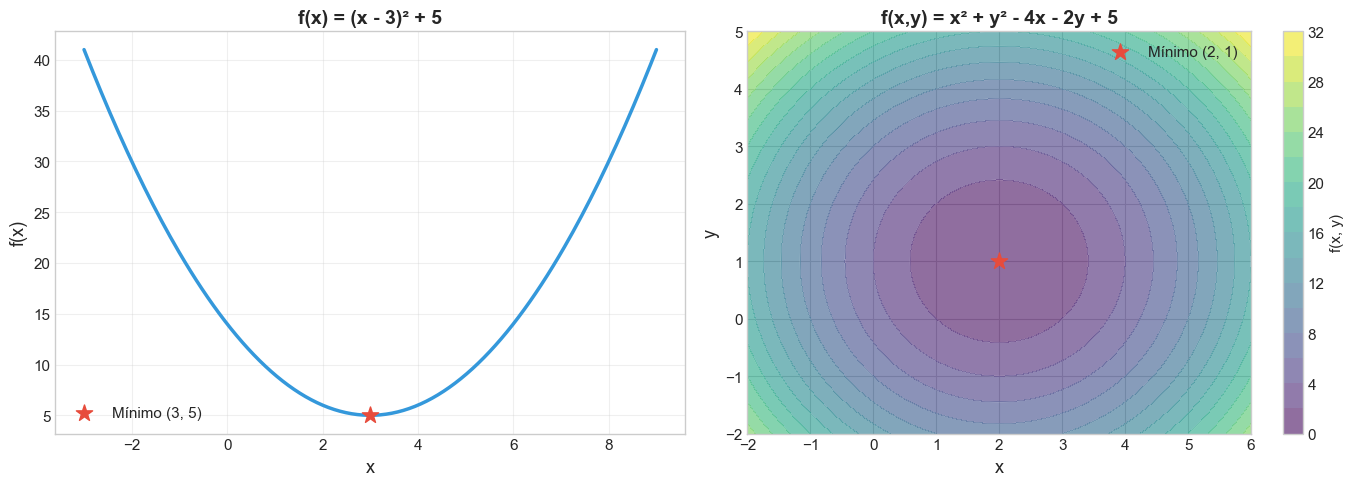

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [3]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float de manera aleatoria
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """

    x_actual = float(np.random.uniform(-10, 10)) if x_inicial is None else x_inicial
    historial_x = [x_actual]
    historial_f = [f_1d(x_actual)]
    convergido = False

    for i in range(max_iter):
        g = df_1d(x_actual)
        x_nuevo = x_actual - learning_rate * g

        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))

        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            iteraciones = i + 1
            break

        x_actual = x_nuevo
    else:
        iteraciones = max_iter

    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': iteraciones,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }
    
    

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [4]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


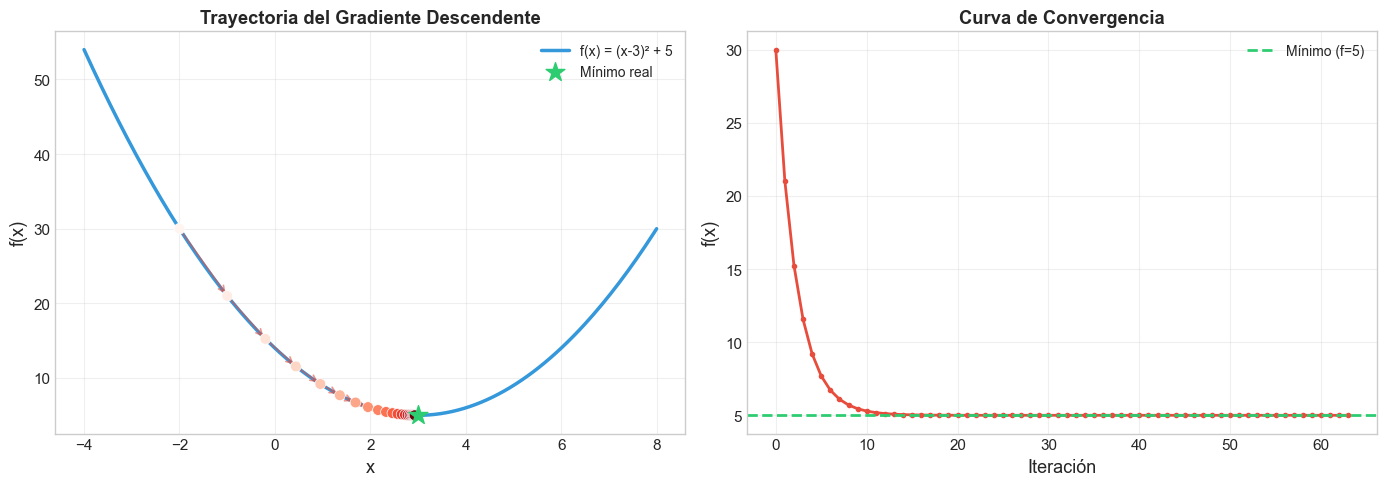

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [6]:
learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0]
#learning_rates_prueba = [1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

resultados_lr = []

for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(res)

# Tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)
for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

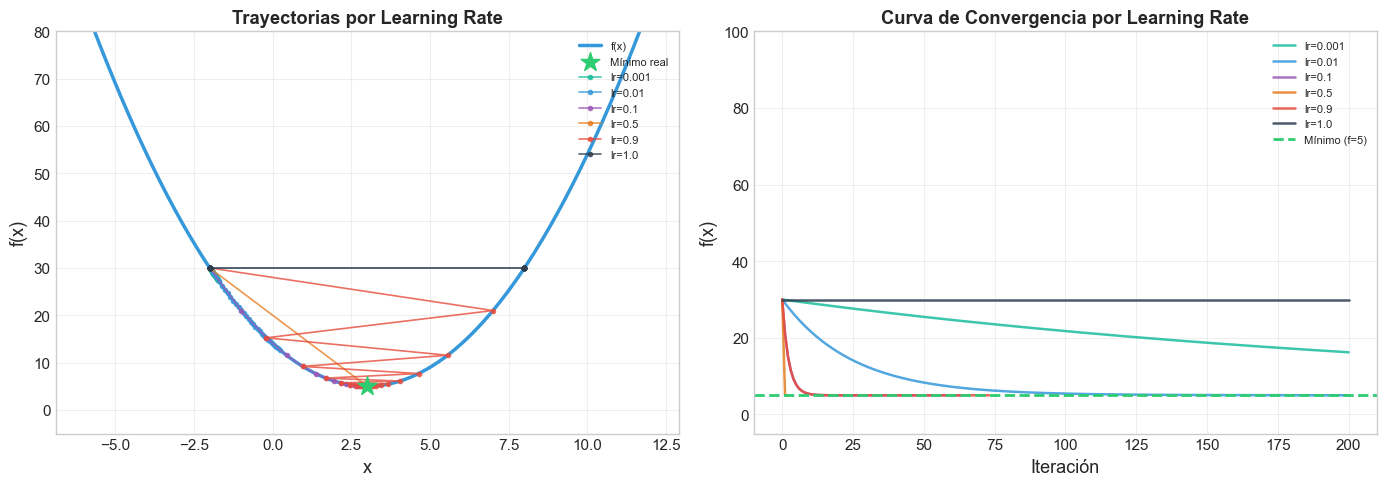

In [7]:
colors = ['#1abc9c', '#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#2c3e50', '#f39c12']
x_range = np.linspace(-6, 12, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Trayectoria sobre f(x)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x)', zorder=1)
axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='Mínimo real')

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colors):
    hx = res['historial_x']
    hf = res['historial_f']
    n = min(30, len(hx))
    axes[0].plot(hx[:n], hf[:n], 'o-', color=color, markersize=3,
                 linewidth=1.2, alpha=0.8, label=f'lr={lr}')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectorias por Learning Rate', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_ylim(-5, 80)
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Curva de convergencia
for lr, res, color in zip(learning_rates_prueba, resultados_lr, colors):
    hf = res['historial_f']
    axes[1].plot(range(len(hf)), hf, '-', color=color, linewidth=1.8,
                 alpha=0.85, label=f'lr={lr}')

axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia por Learning Rate', fontweight='bold')
axes[1].set_ylim(-5, 100)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_lr_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


**Responde estas preguntas basandote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - *Con lr=0.001 el algoritmo converge muy lento, necesita muchas más iteraciones para llegar al mínimo*

2. **¿Cuál consideras el mejor learning rate y por qué?**
   - *lr= 0.1, aunque 0.5 lo hizo solamente en 2 iteraciones, los saltos son excesivamente grandes, con alguna función diferente pudo haberse "pasado" del mínimo, encambio 0.1  fue el segundo mejor en número de iteraciones, y tuvo un comportamiento más estable*

3. **¿Qué pasa con learning rates >= 1.0?**
   - *No convergen, oscilan y lleagan a un resultado mayor al real, pasa lo mismo con 0.9*

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - *Con lr=1.0 exactamente, la actualización x = x - 1.0 * 2(x-3) hace que x salte al otro lado simétricamente alrededor del mínimo sin avanzar (ciclo infinito entre dos puntos)*

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [8]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_actual]
    historial_y = [y_actual]
    historial_f = [f_2d(x_actual, y_actual)]
    convergido = False

    for i in range(max_iter):
        g = grad_2d(x_actual, y_actual)
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]

        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))

        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual, y_actual = x_nuevo, y_nuevo
            iteraciones = i + 1
            break

        x_actual, y_actual = x_nuevo, y_nuevo
    else:
        iteraciones = max_iter

    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': iteraciones,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [9]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


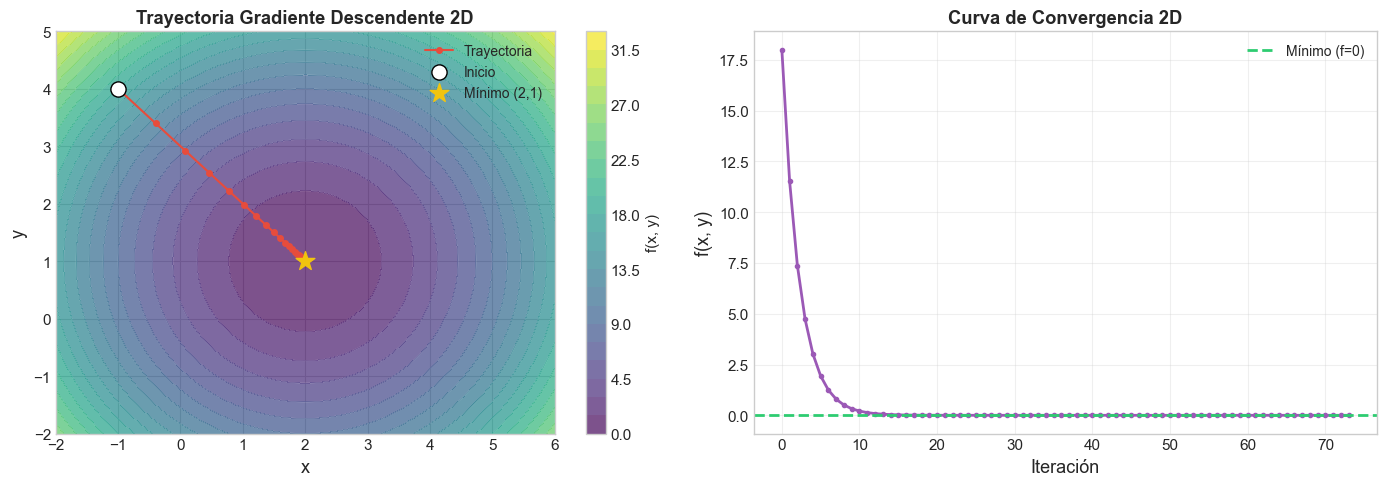

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

# Gráfica 1: Mapa de contornos con trayectoria
contour = axes[0].contourf(X2, Y2, Z2, levels=25, cmap='viridis', alpha=0.7)
axes[0].contour(X2, Y2, Z2, levels=25, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[0], label='f(x, y)')

hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']
n = min(50, len(hx))
axes[0].plot(hx[:n], hy[:n], 'o-', color='#e74c3c', markersize=4,
             linewidth=1.5, label='Trayectoria', zorder=5)
axes[0].scatter([hx[0]], [hy[0]], color='white', s=120, zorder=6, label='Inicio', marker='o', edgecolors='black')
axes[0].scatter([2], [1], color='#f1c40f', s=200, marker='*', zorder=7, label='Mínimo (2,1)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Trayectoria Gradiente Descendente 2D', fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfica 2: Convergencia
axes[1].plot(range(len(resultado_2d['historial_f'])), resultado_2d['historial_f'],
             'o-', color='#9b59b6', linewidth=2, markersize=3)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=0)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x, y)', fontsize=13)
axes[1].set_title('Curva de Convergencia 2D', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

Inicio ( -1.0,   4.0) → Final (2.0000, 1.0000) | f=0.0000 | iter=73
Inicio (  5.0,  -1.0) → Final (2.0000, 1.0000) | f=0.0000 | iter=72
Inicio (  0.0,   0.0) → Final (2.0000, 1.0000) | f=0.0000 | iter=70


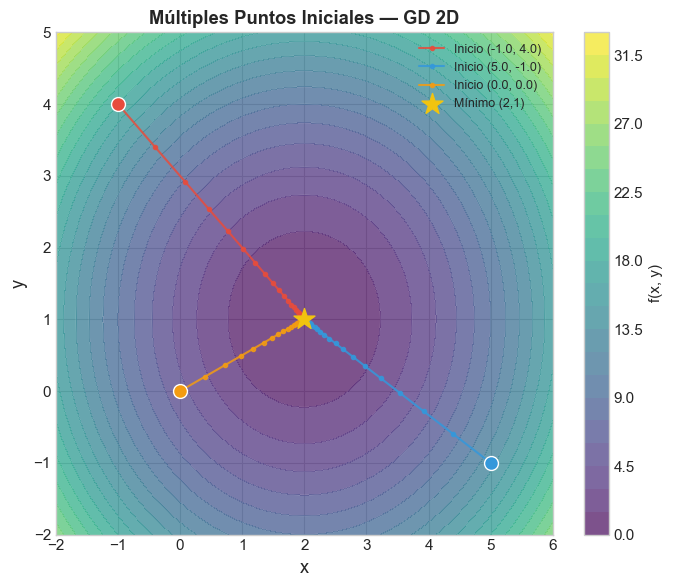

In [11]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

puntos_iniciales = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]
colores_pts = ['#e74c3c', '#3498db', '#f39c12']

fig, ax = plt.subplots(figsize=(7, 6))
contour = ax.contourf(X2, Y2, Z2, levels=25, cmap='viridis', alpha=0.7)
ax.contour(X2, Y2, Z2, levels=25, colors='white', alpha=0.25, linewidths=0.5)
plt.colorbar(contour, ax=ax, label='f(x, y)')

for (xi, yi), color in zip(puntos_iniciales, colores_pts):
    res = gradiente_descendente_2d(xi, yi, learning_rate=0.1, max_iter=200)
    hx, hy = res['historial_x'], res['historial_y']

    ax.plot(hx, hy, 'o-', color=color, markersize=3, linewidth=1.5,
            label=f'Inicio ({xi}, {yi})', alpha=0.85)
    
    ax.scatter([xi], [yi], color=color, s=100, zorder=6, edgecolors='white')
    
    print(f"Inicio ({xi:5.1f}, {yi:5.1f}) → Final ({res['x_final']:.4f}, {res['y_final']:.4f}) | "
          f"f={res['f_final']:.4f} | iter={res['iteraciones']}")

ax.scatter([2], [1], color='#f1c40f', s=250, marker='*', zorder=7, label='Mínimo (2,1)')
ax.set_xlabel('x', fontsize=13); ax.set_ylabel('y', fontsize=13)
ax.set_title('Múltiples Puntos Iniciales — GD 2D', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [12]:
filas = []

# Experimentos 1D
for lr in [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr, 'dimension': '1D',
        'x_inicial': -2.0, 'y_inicial': np.nan,
        'x_final': res['x_final'], 'y_final': np.nan,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

# Experimentos 2D
for lr in [0.001, 0.01, 0.1, 0.5]:
    for (xi, yi) in [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]:
        res = gradiente_descendente_2d(xi, yi, learning_rate=lr, max_iter=500)
        filas.append({
            'learning_rate': lr, 'dimension': '2D',
            'x_inicial': xi, 'y_inicial': yi,
            'x_final': res['x_final'], 'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

df_experimentos = pd.DataFrame(filas)
df_experimentos.to_csv('experimentos_gd.csv', index=False)



In [13]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final  y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01      NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00      NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00      NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00      NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60      NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0  8.974662e-01 2.102534  2.431161e+00          5

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - *El rango que funciona bien es aproximadamente [0.01, 0.5] para estas funciones cuadráticas*

2. **El punto inicial afecta si el algoritmo converge? \¿Afecta cuántas iteraciones necesita?**
   - *El punto inicial no afecta si converge (estas funciones son convexas, siempre hay un único mínimo), pero sí afecta cuántas iteraciones necesita, los puntos más lejanos requieren más pasos*

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x^10`)**
   - *Con múltiples mínimos locales, el GD puede quedar atrapado en un mínimo local dependiendo del punto de inicio, sin garantía de encontrar el global*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`.Por qué es importante elegir bien el learning rate al entrenar?**
   - *Un lr muy pequeño hace el entrenamiento muy lento; uno muy grande hace que los pesos oscilen o diverjan y el modelo nunca aprende correctamente*

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *El gradiente apunta en la dirección de mayor descenso, por lo que cada paso es informado y eficiente. Probar valores al azar sería ineficiente y no escala a espacios de muchas dimensiones (como los millones de parámetros de una red neuronal)*

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [14]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [15]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    w, b = 0.0, 0.0
    n = len(X)
    historial_loss, historial_w, historial_b = [], [], []

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffle, y_shuffle = X[indices], y[indices]

        for start in range(0, n, batch_size):
            X_batch = X_shuffle[start:start + batch_size]
            y_batch = y_shuffle[start:start + batch_size]

            y_pred = w * X_batch + b
            error = y_batch - y_pred

            dw = -2 / len(X_batch) * np.sum(error * X_batch)
            db = -2 / len(X_batch) * np.sum(error)

            w -= learning_rate * dw
            b -= learning_rate * db

        mse = np.mean((y - (w * X + b)) ** 2)
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final': w, 'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }


w aprendida: 3.1819  (real: 3.0)
b aprendida: 6.1485  (real: 7.0)


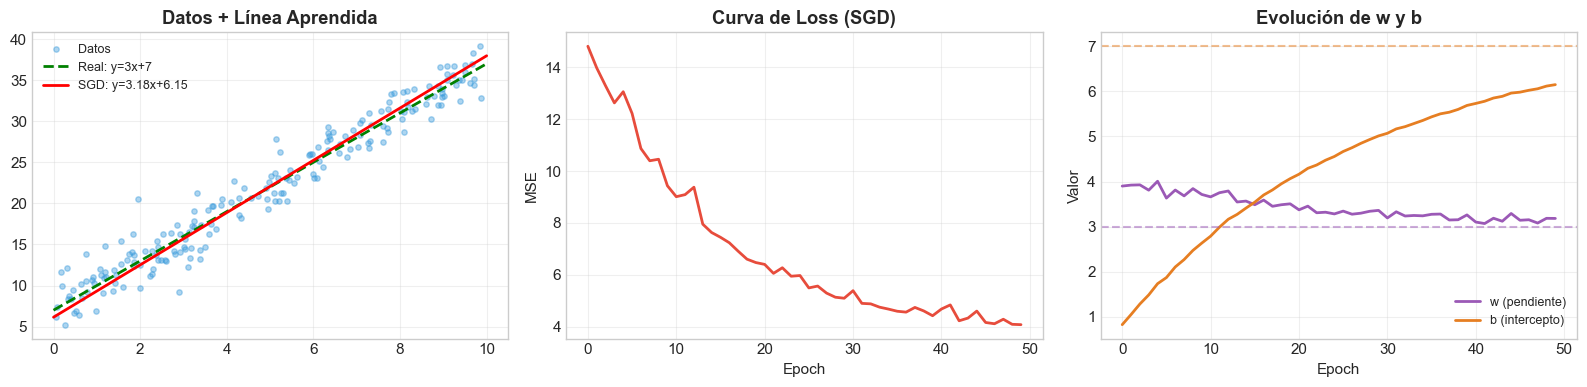

In [16]:

# Ejecutar y visualizar
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

print(f"w aprendida: {resultado_sgd['w_final']:.4f}  (real: 3.0)")
print(f"b aprendida: {resultado_sgd['b_final']:.4f}  (real: 7.0)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Datos + línea aprendida
axes[0].scatter(X_sgd, y_sgd, alpha=0.4, s=15, label='Datos', color='#3498db')
x_line = np.linspace(0, 10, 100)
axes[0].plot(x_line, 3 * x_line + 7, 'g--', linewidth=2, label='Real: y=3x+7')
axes[0].plot(x_line, resultado_sgd['w_final'] * x_line + resultado_sgd['b_final'],
             'r-', linewidth=2, label=f"SGD: y={resultado_sgd['w_final']:.2f}x+{resultado_sgd['b_final']:.2f}")
axes[0].set_title('Datos + Línea Aprendida', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Loss por epoch
axes[1].plot(resultado_sgd['historial_loss'], color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].set_title('Curva de Loss (SGD)', fontweight='bold'); axes[1].grid(True, alpha=0.3)

# Evolución de w y b
axes[2].plot(resultado_sgd['historial_w'], label='w (pendiente)', color='#9b59b6', linewidth=2)
axes[2].plot(resultado_sgd['historial_b'], label='b (intercepto)', color='#e67e22', linewidth=2)
axes[2].axhline(3, color='#9b59b6', linestyle='--', alpha=0.5)
axes[2].axhline(7, color='#e67e22', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Valor')
axes[2].set_title('Evolución de w y b', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_regresion.png', dpi=150, bbox_inches='tight')
plt.show()


COMPARACIÓN GD vs SGD — DIFERENTES BATCH SIZES
Variante                  w_final    b_final   Loss final
-------------------------------------------------------
SGD puro (bs=1)            3.1652     7.2894       4.9282
bs=8                       2.9206     7.2004       3.8719
bs=32                      3.1347     6.1625       4.0334
bs=64                      3.1576     4.8955       6.1755
GD puro (bs=200)           3.7556     2.1410      10.6685


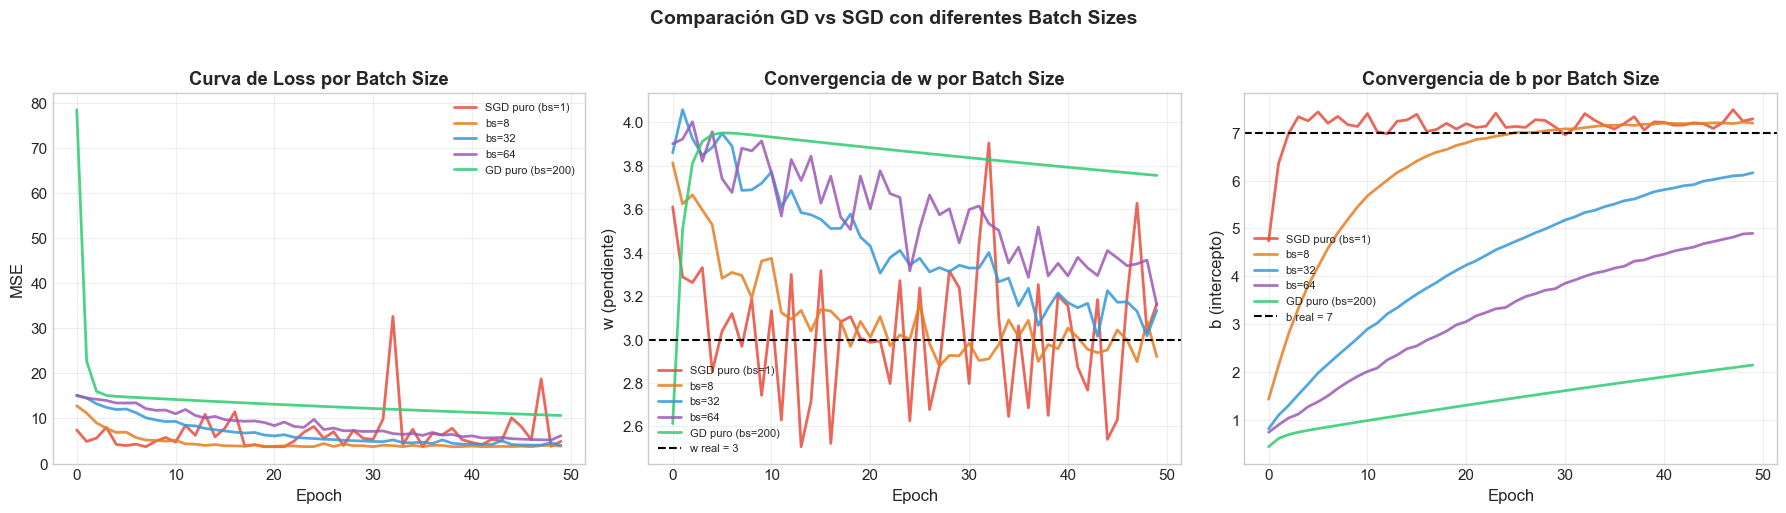

In [17]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro
labels = ['SGD puro (bs=1)', 'bs=8', 'bs=32', 'bs=64', f'GD puro (bs={n_datos})']
colors = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#2ecc71']

resultados_bs = {}
for bs, label in zip(batch_sizes, labels):
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_bs[label] = res

# Tabla resumen
print("COMPARACIÓN GD vs SGD — DIFERENTES BATCH SIZES")
print("=" * 70)
print(f"{'Variante':<22} {'w_final':>10} {'b_final':>10} {'Loss final':>12}")
print("-" * 55)
for label, res in resultados_bs.items():
    print(f"{label:<22} {res['w_final']:>10.4f} {res['b_final']:>10.4f} {res['historial_loss'][-1]:>12.4f}")

# ---- Visualización ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Curvas de loss por epoch
for (label, res), color in zip(resultados_bs.items(), colors):
    axes[0].plot(res['historial_loss'], label=label, color=color, linewidth=2, alpha=0.85)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Curva de Loss por Batch Size', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Evolución del parámetro w
for (label, res), color in zip(resultados_bs.items(), colors):
    axes[1].plot(res['historial_w'], label=label, color=color, linewidth=2, alpha=0.85)
axes[1].axhline(3, color='black', linestyle='--', linewidth=1.5, label='w real = 3')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('w (pendiente)', fontsize=12)
axes[1].set_title('Convergencia de w por Batch Size', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Gráfica 3: Evolución del parámetro b
for (label, res), color in zip(resultados_bs.items(), colors):
    axes[2].plot(res['historial_b'], label=label, color=color, linewidth=2, alpha=0.85)
axes[2].axhline(7, color='black', linestyle='--', linewidth=1.5, label='b real = 7')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('b (intercepto)', fontsize=12)
axes[2].set_title('Convergencia de b por Batch Size', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparación GD vs SGD con diferentes Batch Sizes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gd_vs_sgd_batch_sizes.png', dpi=150, bbox_inches='tight')
plt.show()



**Preguntas Bonus:**

1. **\u00bfQu\u00e9 diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta:*

2. **\u00bfCu\u00e1l batch_size te dio los mejores resultados? \u00bfPor qu\u00e9?**
   - *Tu respuesta:*

3. **\u00bfPor qu\u00e9 la curva de loss de SGD es m\u00e1s ruidosa que la de GD?**
   - *Tu respuesta:*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_